BDRY (해운 운임 ETF) 데이터 수집 중...


[*********************100%***********************]  1 of 1 completed


✅ 'shipping_index_5yr.csv' 파일 저장 완료!


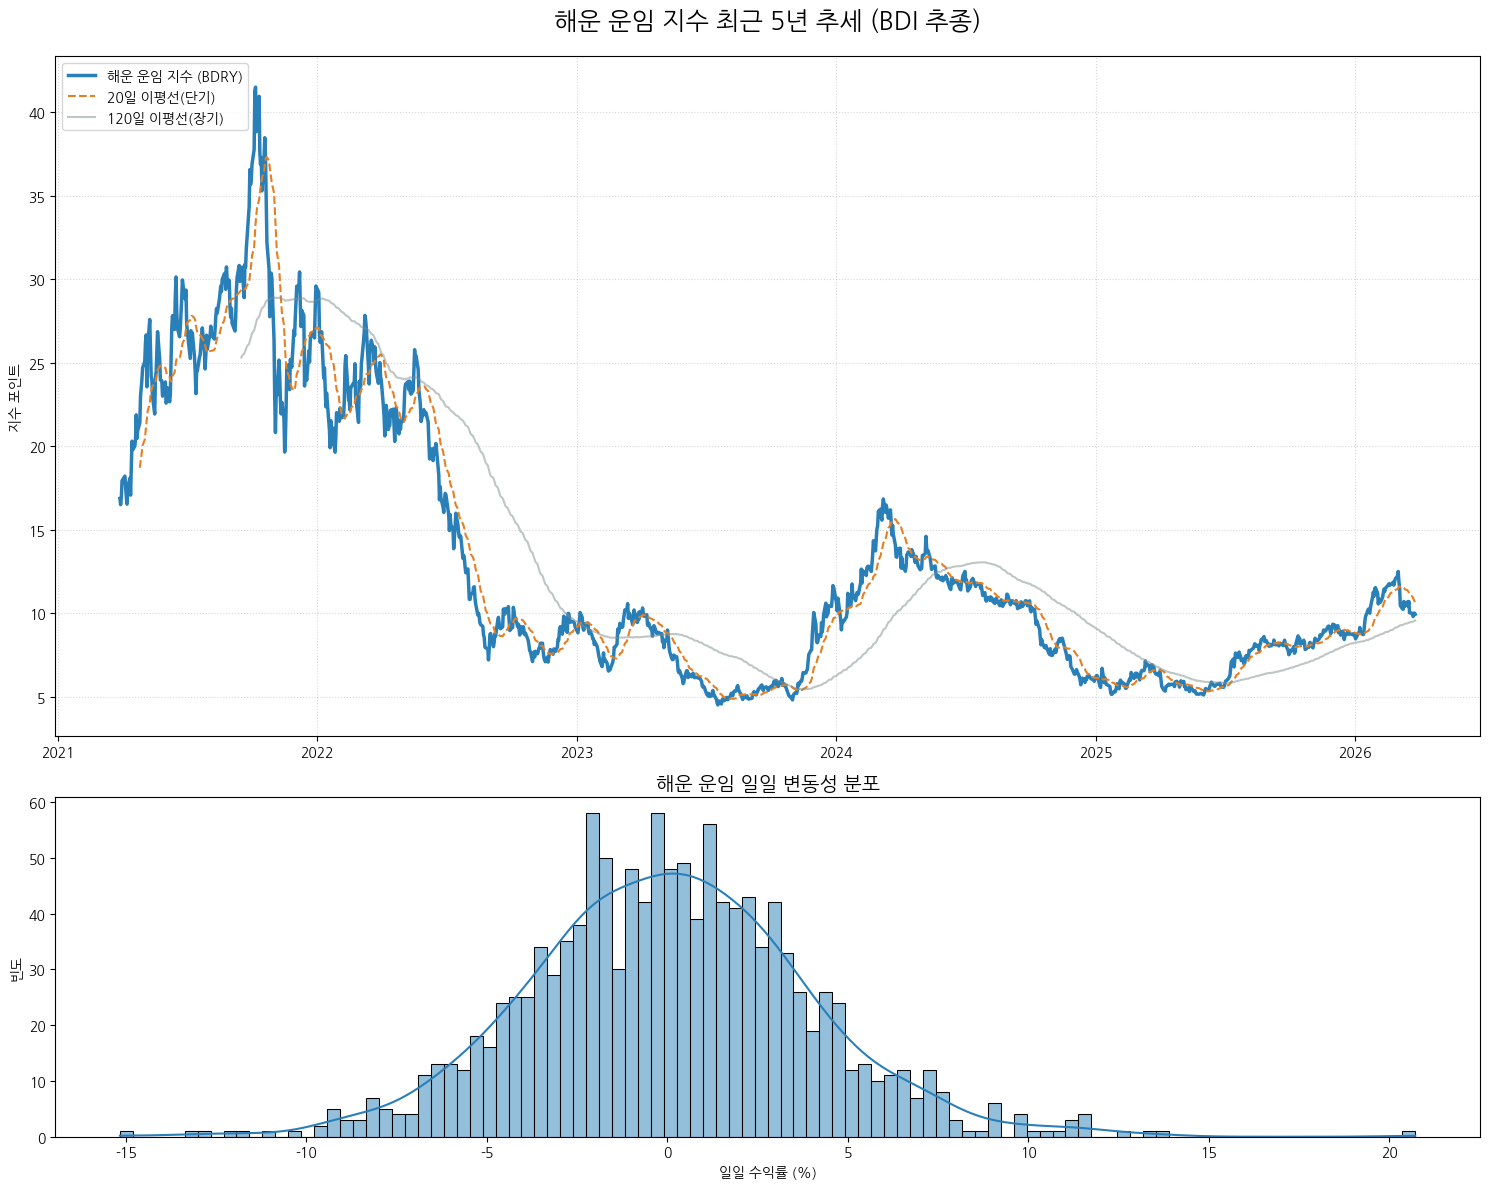


--- BDRY 분석 요약 ---
현재 운임 수준: 9.93
5년 최고점: 41.51
평균 변동성: ±3.92%


In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
from datetime import datetime, timedelta

# 1. 데이터 수집 (BDRY: 건화물선 운임 지수를 추종하는 ETF)
ticker = "BDRY"
end = datetime.now()
start = end - timedelta(days=5*365)

print(f"{ticker} (해운 운임 ETF) 데이터 수집 중...")
df = yf.download(ticker, start=start, end=end, auto_adjust=True)

# Multi-index 처리
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 2. 데이터 가공
df['일일수익률'] = df['Close'].pct_change() * 100
df['20일평균'] = df['Close'].rolling(window=20).mean()
df['120일평균'] = df['Close'].rolling(window=120).mean() # 해운은 장기 사이클이 중요해서 120일 추가

# 3. CSV 파일 저장
file_name = "shipping_index_5yr.csv"
df.to_csv(file_name)
print(f"✅ '{file_name}' 파일 저장 완료!")

# 4. 시각화 (해운 특화 분석)
fig, ax = plt.subplots(2, 1, figsize=(15, 12), gridspec_kw={'height_ratios': [2, 1]})

# [상단] 운임 추세 및 장단기 이평선
ax[0].plot(df.index, df['Close'], label='해운 운임 지수 (BDRY)', color='#2980B9', linewidth=2.5)
ax[0].plot(df.index, df['20일평균'], label='20일 이평선(단기)', color='#E67E22', linestyle='--')
ax[0].plot(df.index, df['120일평균'], label='120일 이평선(장기)', color='#7F8C8D', linestyle='-', alpha=0.5)

ax[0].set_title('해운 운임 지수 최근 5년 추세 (BDI 추종)', fontsize=18, pad=20)
ax[0].set_ylabel('지수 포인트')
ax[0].legend(loc='upper left')
ax[0].grid(True, linestyle=':', alpha=0.5)

# [하단] 운임 변동성 (수익률)
sns.histplot(df['일일수익률'].dropna(), bins=100, kde=True, ax=ax[1], color='#2980B9')
ax[1].set_title('해운 운임 일일 변동성 분포', fontsize=14)
ax[1].set_xlabel('일일 수익률 (%)')
ax[1].set_ylabel('빈도')

plt.tight_layout()
plt.show()

# 5. 주요 통계치 출력
print(f"\n--- {ticker} 분석 요약 ---")
print(f"현재 운임 수준: {df['Close'].iloc[-1]:.2f}")
print(f"5년 최고점: {df['Close'].max():.2f}")
print(f"평균 변동성: ±{df['일일수익률'].std():.2f}%")